PASSO 1 — Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

metadata_path = '/content/drive/MyDrive/tcc_skin_cancer/HAM10000_metadata.csv'

df = pd.read_csv(metadata_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [6]:
df['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [7]:
import os
from glob import glob

image_path_1 = '/content/drive/MyDrive/tcc_skin_cancer/ham10000_images_part_1/*.jpg'
image_path_2 = '/content/drive/MyDrive/tcc_skin_cancer/ham10000_images_part_2/*.jpg'

all_image_paths = glob(image_path_1) + glob(image_path_2)

print("Quantidade de imagens encontradas:", len(all_image_paths))

Quantidade de imagens encontradas: 10015


In [9]:
imageid_path_dict = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in all_image_paths
}

In [10]:
df['path'] = df['image_id'].map(imageid_path_dict.get)

In [11]:
df[['image_id', 'path']].head()

,image_id,path
0,ISIC_0027419,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
1,ISIC_0025030,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
2,ISIC_0026769,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
3,ISIC_0025661,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
4,ISIC_0031633,/content/drive/MyDrive/tcc_skin_cancer/ham1000...


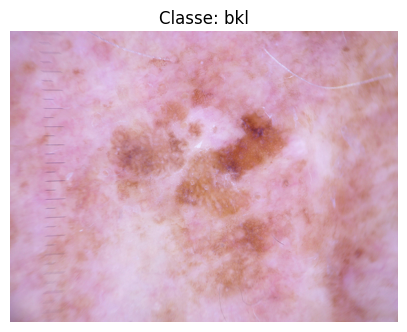

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

sample = df.iloc[0]

img = Image.open(sample['path'])

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"Classe: {sample['dx']}")
plt.axis('off')
plt.show()

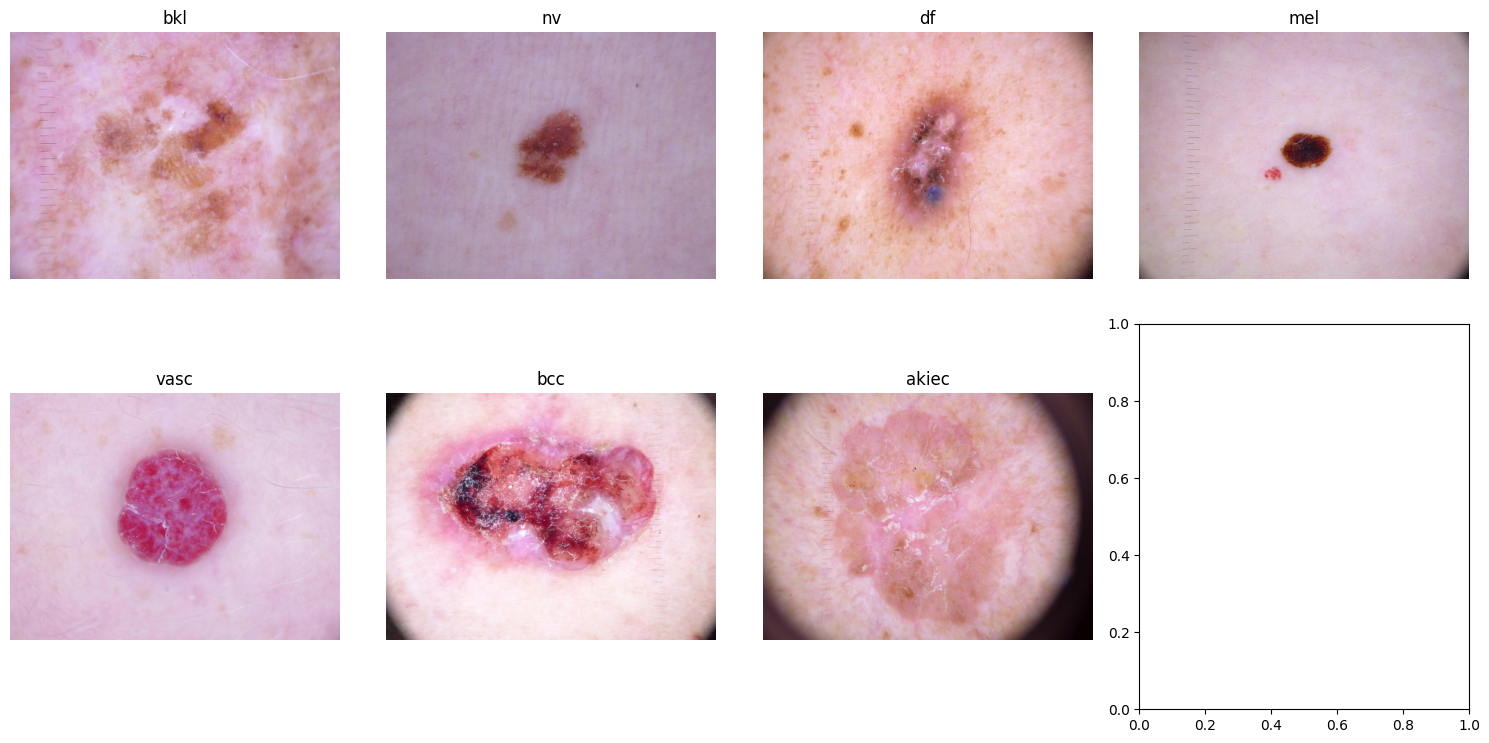

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

classes = df['dx'].unique()

for ax, lesion in zip(axes.flatten(), classes):

    sample = df[df['dx'] == lesion].iloc[0]

    img = Image.open(sample['path'])

    ax.imshow(img)
    ax.set_title(lesion)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

df['lesion_type'] = df['dx'].map(lesion_type_dict)

print(df.columns)
df[['image_id', 'dx', 'lesion_type', 'binary_label', 'binary_label_name', 'path']].head()

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'path', 'binary_label', 'binary_label_name', 'lesion_type'],
      dtype='object')


,image_id,dx,lesion_type,binary_label,binary_label_name,path
0,ISIC_0027419,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
1,ISIC_0025030,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
2,ISIC_0026769,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
3,ISIC_0025661,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
4,ISIC_0031633,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...


In [17]:
suspect_classes = ['mel', 'bcc', 'akiec']

df['binary_label'] = df['dx'].apply(lambda x: 1 if x in suspect_classes else 0)

df['binary_label'].value_counts()

,count
binary_label,
0,8061
1,1954


In [18]:
df['binary_label_name'] = df['binary_label'].map({
    0: 'nao_suspeito',
    1: 'suspeito'
})

df[['image_id', 'dx', 'lesion_type', 'binary_label', 'binary_label_name', 'path']].head()

,image_id,dx,lesion_type,binary_label,binary_label_name,path
0,ISIC_0027419,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
1,ISIC_0025030,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
2,ISIC_0026769,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
3,ISIC_0025661,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...
4,ISIC_0031633,bkl,Benign keratosis-like lesions,0,nao_suspeito,/content/drive/MyDrive/tcc_skin_cancer/ham1000...


In [19]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['binary_label'],
    random_state=42
)

In [20]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['binary_label'],
    random_state=42
)

In [21]:
print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

Treino: 7010
Validação: 1502
Teste: 1503


In [22]:
print("\nTreino")
print(train_df['binary_label'].value_counts(normalize=True))

print("\nValidação")
print(val_df['binary_label'].value_counts(normalize=True))

print("\nTeste")
print(test_df['binary_label'].value_counts(normalize=True))


Treino
binary_label
0    0.80485
1    0.19515
Name: proportion, dtype: float64

Validação
binary_label
0    0.804927
1    0.195073
Name: proportion, dtype: float64

Teste
binary_label
0    0.805057
1    0.194943
Name: proportion, dtype: float64


In [23]:
train_df['binary_label_name'] = train_df['binary_label_name'].astype(str)
val_df['binary_label_name'] = val_df['binary_label_name'].astype(str)
test_df['binary_label_name'] = test_df['binary_label_name'].astype(str)

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [25]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.


In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 2590s 12s/step - accuracy: 0.7974 - loss: 0.4709 - val_accuracy: 0.8049 - val_loss: 0.4786
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 162s 736ms/step - accuracy: 0.8046 - loss: 0.4329 - val_accuracy: 0.8049 - val_loss: 0.4299
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 161s 733ms/step - accuracy: 0.8050 - loss: 0.4179 - val_accuracy: 0.8049 - val_loss: 0.5845
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 163s 740ms/step - accuracy: 0.8046 - loss: 0.4963 - val_accuracy: 0.8049 - val_loss: 0.4671
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 161s 730ms/step - accuracy: 0.8049 - loss: 0.4508 - val_accuracy: 0.8049 - val_loss: 0.4483


In [28]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_generator.reset()

pred_probs = model.predict(test_generator)
pred_classes = (pred_probs > 0.5).astype(int).ravel()

true_classes = test_generator.classes

print(classification_report(true_classes, pred_classes, target_names=['nao_suspeito', 'suspeito']))

print(confusion_matrix(true_classes, pred_classes))

47/47 ━━━━━━━━━━━━━━━━━━━━ 435s 9s/step
              precision    recall  f1-score   support

nao_suspeito       0.81      1.00      0.89      1210
    suspeito       0.00      0.00      0.00       293

    accuracy                           0.81      1503
   macro avg       0.40      0.50      0.45      1503
weighted avg       0.65      0.81      0.72      1503

[[1210    0]
 [ 293    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['binary_label']),
    y=train_df['binary_label']
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.6212336051045728), 1: np.float64(2.5621345029239766)}


In [30]:
history_weighted = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 166s 742ms/step - accuracy: 0.6113 - loss: 0.6054 - val_accuracy: 0.5652 - val_loss: 0.5192
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 174s 791ms/step - accuracy: 0.5807 - loss: 0.5643 - val_accuracy: 0.5266 - val_loss: 0.5497
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 164s 748ms/step - accuracy: 0.7488 - loss: 0.6915 - val_accuracy: 0.8049 - val_loss: 0.6823
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 163s 741ms/step - accuracy: 0.8049 - loss: 0.6933 - val_accuracy: 0.8049 - val_loss: 0.6858
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 165s 751ms/step - accuracy: 0.8049 - loss: 0.6932 - val_accuracy: 0.8049 - val_loss: 0.6877


In [31]:
test_generator.reset()

pred_probs = model.predict(test_generator)
pred_classes = (pred_probs > 0.5).astype(int).ravel()

true_classes = test_generator.classes

print(classification_report(true_classes, pred_classes, target_names=['nao_suspeito', 'suspeito']))
print(confusion_matrix(true_classes, pred_classes))

47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 346ms/step
              precision    recall  f1-score   support

nao_suspeito       0.81      1.00      0.89      1210
    suspeito       0.00      0.00      0.00       293

    accuracy                           0.81      1503
   macro avg       0.40      0.50      0.45      1503
weighted avg       0.65      0.81      0.72      1503

[[1210    0]
 [ 293    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator_resnet = train_datagen_resnet.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_generator_resnet = val_test_datagen_resnet.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator_resnet = val_test_datagen_resnet.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.


In [33]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

resnet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [34]:
history_resnet = resnet_model.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 194s 819ms/step - accuracy: 0.7312 - loss: 0.5278 - val_accuracy: 0.8309 - val_loss: 0.3496
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 163s 739ms/step - accuracy: 0.7660 - loss: 0.4433 - val_accuracy: 0.7603 - val_loss: 0.4397
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 163s 740ms/step - accuracy: 0.7626 - loss: 0.4260 - val_accuracy: 0.8036 - val_loss: 0.3981
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 174s 793ms/step - accuracy: 0.7685 - loss: 0.4117 - val_accuracy: 0.7290 - val_loss: 0.4803
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 172s 783ms/step - accuracy: 0.7638 - loss: 0.4176 - val_accuracy: 0.7563 - val_loss: 0.4241


In [35]:
test_generator_resnet.reset()

pred_probs_resnet = resnet_model.predict(test_generator_resnet)
pred_classes_resnet = (pred_probs_resnet > 0.5).astype(int).ravel()

true_classes_resnet = test_generator_resnet.classes

print(classification_report(true_classes_resnet, pred_classes_resnet, target_names=['nao_suspeito', 'suspeito']))
print(confusion_matrix(true_classes_resnet, pred_classes_resnet))

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 468ms/step
              precision    recall  f1-score   support

nao_suspeito       0.96      0.77      0.85      1210
    suspeito       0.47      0.86      0.61       293

    accuracy                           0.79      1503
   macro avg       0.72      0.81      0.73      1503
weighted avg       0.86      0.79      0.80      1503

[[927 283]
 [ 40 253]]


In [36]:
import os

MODEL_DIR = '/content/drive/MyDrive/tcc_skin_cancer/models'
os.makedirs(MODEL_DIR, exist_ok=True)

In [37]:
resnet_model.save(f'{MODEL_DIR}/resnet50_transfer_learning_baseline.keras')

In [38]:
os.listdir(MODEL_DIR)

['resnet50_transfer_learning_baseline.keras']

In [39]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [40]:
from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [41]:
history_resnet_finetune = resnet_model.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 198s 810ms/step - accuracy: 0.7776 - loss: 0.4343 - val_accuracy: 0.7916 - val_loss: 0.4118
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 166s 754ms/step - accuracy: 0.7926 - loss: 0.3780 - val_accuracy: 0.7996 - val_loss: 0.4212
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 166s 754ms/step - accuracy: 0.8053 - loss: 0.3596 - val_accuracy: 0.8103 - val_loss: 0.3922
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 164s 745ms/step - accuracy: 0.8285 - loss: 0.3320 - val_accuracy: 0.8156 - val_loss: 0.3888
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 166s 754ms/step - accuracy: 0.8494 - loss: 0.2942 - val_accuracy: 0.8489 - val_loss: 0.3412


In [42]:
test_generator_resnet.reset()

pred_probs_finetune = resnet_model.predict(test_generator_resnet)
pred_classes_finetune = (pred_probs_finetune > 0.5).astype(int).ravel()

true_classes_finetune = test_generator_resnet.classes

print(classification_report(true_classes_finetune, pred_classes_finetune, target_names=['nao_suspeito', 'suspeito']))
print(confusion_matrix(true_classes_finetune, pred_classes_finetune))

47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 463ms/step
              precision    recall  f1-score   support

nao_suspeito       0.94      0.88      0.91      1210
    suspeito       0.60      0.77      0.68       293

    accuracy                           0.86      1503
   macro avg       0.77      0.82      0.79      1503
weighted avg       0.87      0.86      0.86      1503

[[1063  147]
 [  68  225]]


In [43]:
resnet_model.save(f'{MODEL_DIR}/resnet50_finetuned.keras')

In [44]:
os.listdir(MODEL_DIR)

['resnet50_transfer_learning_baseline.keras', 'resnet50_finetuned.keras']

In [45]:
for layer in base_model.layers[::-1]:
    if 'conv' in layer.name:
        print(layer.name)
        break

conv5_block3_out


In [46]:
last_conv_layer_name = "conv5_block3_out"

In [47]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    base_model = model.layers[0]

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [48]:
def display_gradcam(img_path, model, last_conv_layer_name, alpha=0.4):
    img = Image.open(img_path).resize((224, 224)).convert("RGB")
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    img_array_preprocessed = preprocess_input(img_array_expanded.copy())

    heatmap = make_gradcam_heatmap(
        img_array_preprocessed,
        model,
        last_conv_layer_name
    )

    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize((224, 224))
    heatmap_resized = np.array(heatmap_resized)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagem original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap_resized, cmap="jet", alpha=alpha)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

In [49]:
sample_suspect = test_df[test_df['binary_label'] == 1].iloc[0]

display_gradcam(
    sample_suspect['path'],
    resnet_model,
    last_conv_layer_name
)

AttributeError: The layer sequential_1 has never been called and thus has no defined output.

In [50]:
dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
_ = resnet_model(dummy)

In [51]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    base_model = model.layers[0]

    conv_layer = base_model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            conv_layer.output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)

    if max_val == 0:
        return heatmap.numpy()

    heatmap /= max_val

    return heatmap.numpy()


def display_gradcam(img_path, model, last_conv_layer_name, alpha=0.4):
    img = Image.open(img_path).resize((224, 224)).convert("RGB")

    img_array = image.img_to_array(img)

    img_array_expanded = np.expand_dims(img_array, axis=0)

    img_array_preprocessed = preprocess_input(img_array_expanded.copy())

    heatmap = make_gradcam_heatmap(
        img_array_preprocessed,
        model,
        last_conv_layer_name
    )

    heatmap_resized = Image.fromarray(
        np.uint8(255 * heatmap)
    ).resize((224, 224))

    heatmap_resized = np.array(heatmap_resized)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagem original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap_resized, cmap="jet", alpha=alpha)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()


sample_suspect = test_df[test_df['binary_label'] == 1].iloc[0]

display_gradcam(
    sample_suspect['path'],
    resnet_model,
    last_conv_layer_name
)

AttributeError: The layer sequential_1 has never been called and thus has no defined output.

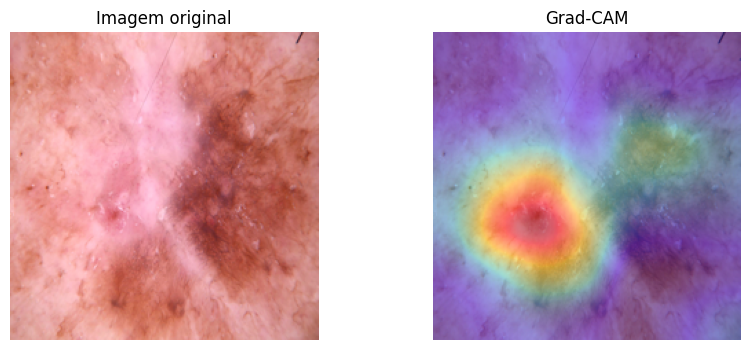

In [53]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    base_model = model.layers[0]

    inputs = base_model.input
    x = base_model.output

    for layer in model.layers[1:]:
        try:
            x = layer(x, training=False)
        except:
            x = layer(x)

    grad_model = tf.keras.models.Model(
        inputs=inputs,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            x
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def display_gradcam(img_path, model, last_conv_layer_name, alpha=0.4):
    img = Image.open(img_path).resize((224, 224)).convert("RGB")

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array.copy())

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    heatmap = Image.fromarray(np.uint8(255 * heatmap)).resize((224, 224))
    heatmap = np.array(heatmap)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagem original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet", alpha=alpha)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()


sample_suspect = test_df[test_df['binary_label'] == 1].iloc[0]

display_gradcam(
    sample_suspect['path'],
    resnet_model,
    "conv5_block3_out"
)

In [54]:
test_results_df = test_df.copy().reset_index(drop=True)

test_results_df['true_label'] = true_classes_finetune
test_results_df['pred_label'] = pred_classes_finetune
test_results_df['pred_prob'] = pred_probs_finetune.ravel()

test_results_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,binary_label,binary_label_name,lesion_type,true_label,pred_label,pred_prob
0,HAM_0002367,ISIC_0034240,nv,histo,60.0,male,abdomen,/content/drive/MyDrive/tcc_skin_cancer/ham1000...,0,nao_suspeito,Melanocytic nevi,0,0,0.010421
1,HAM_0004442,ISIC_0033576,bkl,histo,85.0,male,trunk,/content/drive/MyDrive/tcc_skin_cancer/ham1000...,0,nao_suspeito,Benign keratosis-like lesions,0,1,0.954146
2,HAM_0003146,ISIC_0026992,akiec,histo,85.0,male,upper extremity,/content/drive/MyDrive/tcc_skin_cancer/ham1000...,1,suspeito,Actinic keratoses,1,1,0.967221
3,HAM_0005610,ISIC_0027608,bkl,confocal,65.0,female,face,/content/drive/MyDrive/tcc_skin_cancer/ham1000...,0,nao_suspeito,Benign keratosis-like lesions,0,0,0.459133
4,HAM_0004925,ISIC_0024873,nv,follow_up,35.0,male,back,/content/drive/MyDrive/tcc_skin_cancer/ham1000...,0,nao_suspeito,Melanocytic nevi,0,0,0.000087


In [55]:
true_positive = test_results_df[
    (test_results_df['true_label'] == 1) &
    (test_results_df['pred_label'] == 1)
]

true_negative = test_results_df[
    (test_results_df['true_label'] == 0) &
    (test_results_df['pred_label'] == 0)
]

false_positive = test_results_df[
    (test_results_df['true_label'] == 0) &
    (test_results_df['pred_label'] == 1)
]

false_negative = test_results_df[
    (test_results_df['true_label'] == 1) &
    (test_results_df['pred_label'] == 0)
]

print("Verdadeiro positivo:", len(true_positive))
print("Verdadeiro negativo:", len(true_negative))
print("Falso positivo:", len(false_positive))
print("Falso negativo:", len(false_negative))

Verdadeiro positivo: 225
Verdadeiro negativo: 1063
Falso positivo: 147
Falso negativo: 68


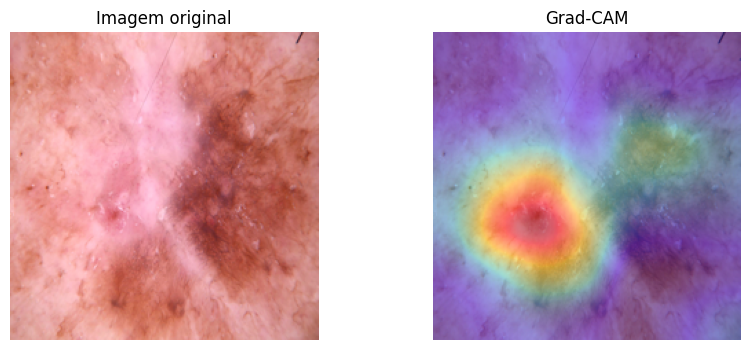

dx              akiec
pred_prob    0.967221
Name: 2, dtype: object


In [56]:
sample_tp = true_positive.iloc[0]

display_gradcam(
    sample_tp['path'],
    resnet_model,
    "conv5_block3_out"
)

print(sample_tp[['dx', 'pred_prob']])

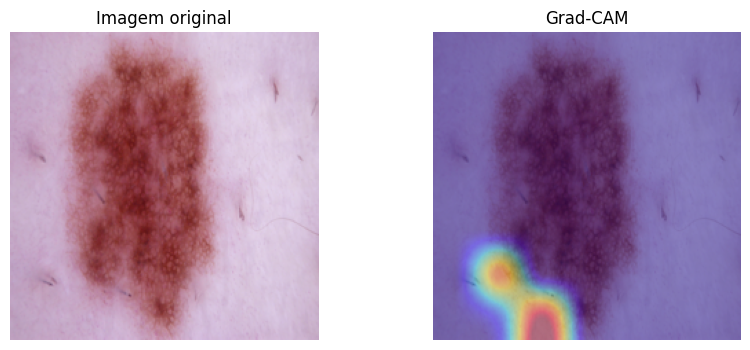

dx                 nv
pred_prob    0.010421
Name: 0, dtype: object


In [57]:
sample_tn = true_negative.iloc[0]

display_gradcam(
    sample_tn['path'],
    resnet_model,
    "conv5_block3_out"
)

print(sample_tn[['dx', 'pred_prob']])

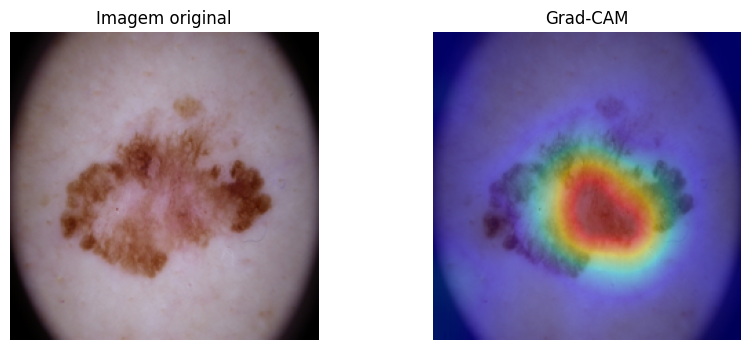

dx                bkl
pred_prob    0.954146
Name: 1, dtype: object


In [58]:
sample_fp = false_positive.iloc[0]

display_gradcam(
    sample_fp['path'],
    resnet_model,
    "conv5_block3_out"
)

print(sample_fp[['dx', 'pred_prob']])

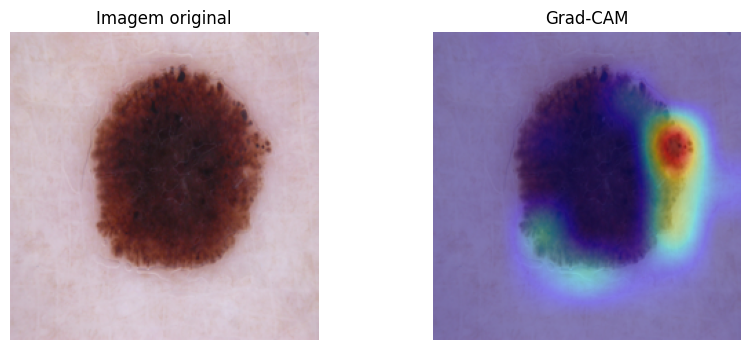

dx                mel
pred_prob    0.358431
Name: 10, dtype: object


In [59]:
sample_fn = false_negative.iloc[0]

display_gradcam(
    sample_fn['path'],
    resnet_model,
    "conv5_block3_out"
)

print(sample_fn[['dx', 'pred_prob']])

In [60]:
resnet_model.save(f'{MODEL_DIR}/resnet50_finetuned.keras')

In [61]:
RESULTS_DIR = '/content/drive/MyDrive/tcc_skin_cancer/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

In [62]:
import pandas as pd

metrics_data = [
    {
        "modelo": "CNN baseline",
        "accuracy": 0.81,
        "precision_suspeito": 0.00,
        "recall_suspeito": 0.00,
        "f1_suspeito": 0.00
    },
    {
        "modelo": "ResNet50 Transfer Learning",
        "accuracy": 0.79,
        "precision_suspeito": 0.47,
        "recall_suspeito": 0.86,
        "f1_suspeito": 0.61
    },
    {
        "modelo": "ResNet50 Fine Tuned",
        "accuracy": 0.86,
        "precision_suspeito": 0.60,
        "recall_suspeito": 0.77,
        "f1_suspeito": 0.68
    }
]

metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(f'{RESULTS_DIR}/metrics_comparison.csv', index=False)

metrics_df

,modelo,accuracy,precision_suspeito,recall_suspeito,f1_suspeito
0,CNN baseline,0.81,0.00,0.00,0.00
1,ResNet50 Transfer Learning,0.79,0.47,0.86,0.61
2,ResNet50 Fine Tuned,0.86,0.60,0.77,0.68


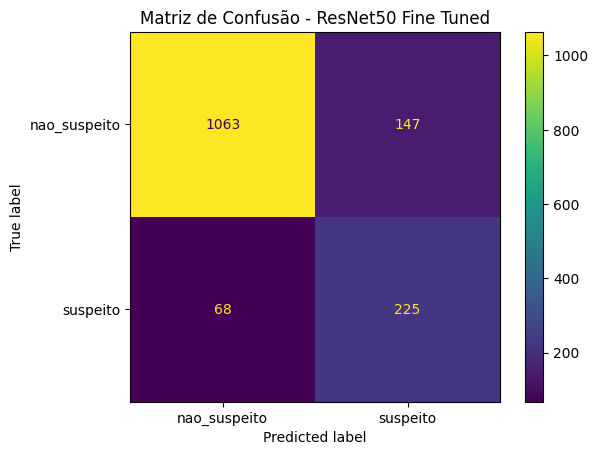

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_finetune = confusion_matrix(true_classes_finetune, pred_classes_finetune)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_finetune,
    display_labels=['nao_suspeito', 'suspeito']
)

disp.plot(values_format='d')
plt.title('Matriz de Confusão - ResNet50 Fine Tuned')
plt.savefig(f'{RESULTS_DIR}/confusion_matrix_resnet50_finetuned.png', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
import os

BASE_DIR = '/content/drive/MyDrive/tcc_skin_cancer'
MODEL_DIR = f'{BASE_DIR}/models'
RESULTS_DIR = f'{BASE_DIR}/results'
GRADCAM_DIR = f'{RESULTS_DIR}/gradcam_examples'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(GRADCAM_DIR, exist_ok=True)

In [65]:
model.save(f'{MODEL_DIR}/cnn_baseline.keras')
resnet_model.save(f'{MODEL_DIR}/resnet50_finetuned.keras')

In [66]:
metrics_data = [
    {
        "modelo": "CNN baseline",
        "accuracy": 0.81,
        "precision_suspeito": 0.00,
        "recall_suspeito": 0.00,
        "f1_suspeito": 0.00,
        "tn": 1210,
        "fp": 0,
        "fn": 293,
        "tp": 0
    },
    {
        "modelo": "ResNet50 Transfer Learning",
        "accuracy": 0.79,
        "precision_suspeito": 0.47,
        "recall_suspeito": 0.86,
        "f1_suspeito": 0.61,
        "tn": 927,
        "fp": 283,
        "fn": 40,
        "tp": 253
    },
    {
        "modelo": "ResNet50 Fine Tuned",
        "accuracy": 0.86,
        "precision_suspeito": 0.60,
        "recall_suspeito": 0.77,
        "f1_suspeito": 0.68,
        "tn": 1063,
        "fp": 147,
        "fn": 68,
        "tp": 225
    }
]

metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(f'{RESULTS_DIR}/metrics_comparison.csv', index=False)
metrics_df

,modelo,accuracy,precision_suspeito,recall_suspeito,f1_suspeito,tn,fp,fn,tp
0,CNN baseline,0.81,0.00,0.00,0.00,1210,0,293,0
1,ResNet50 Transfer Learning,0.79,0.47,0.86,0.61,927,283,40,253
2,ResNet50 Fine Tuned,0.86,0.60,0.77,0.68,1063,147,68,225


In [67]:
from sklearn.metrics import classification_report, confusion_matrix
import json

report_finetune = classification_report(
    true_classes_finetune,
    pred_classes_finetune,
    target_names=['nao_suspeito', 'suspeito'],
    output_dict=True
)

with open(f'{RESULTS_DIR}/classification_report_resnet50_finetuned.json', 'w') as f:
    json.dump(report_finetune, f, indent=4)

pd.DataFrame(report_finetune).transpose().to_csv(
    f'{RESULTS_DIR}/classification_report_resnet50_finetuned.csv'
)

In [68]:
predictions_df = test_results_df.copy()
predictions_df.to_csv(f'{RESULTS_DIR}/test_predictions_resnet50_finetuned.csv', index=False)

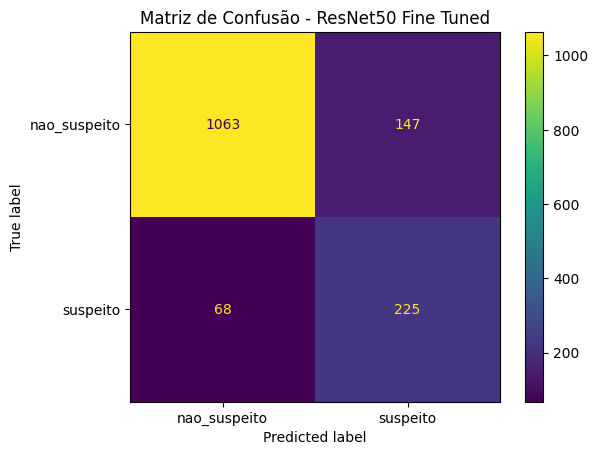

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_finetune = confusion_matrix(true_classes_finetune, pred_classes_finetune)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_finetune,
    display_labels=['nao_suspeito', 'suspeito']
)

disp.plot(values_format='d')
plt.title('Matriz de Confusão - ResNet50 Fine Tuned')
plt.savefig(f'{RESULTS_DIR}/confusion_matrix_resnet50_finetuned.png', dpi=300, bbox_inches='tight')
plt.show()

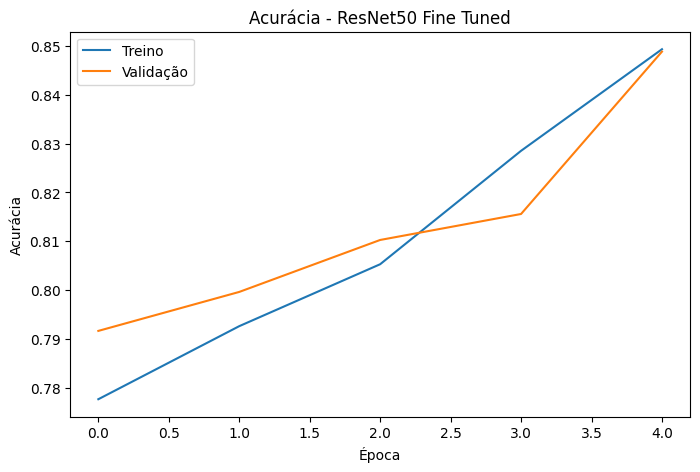

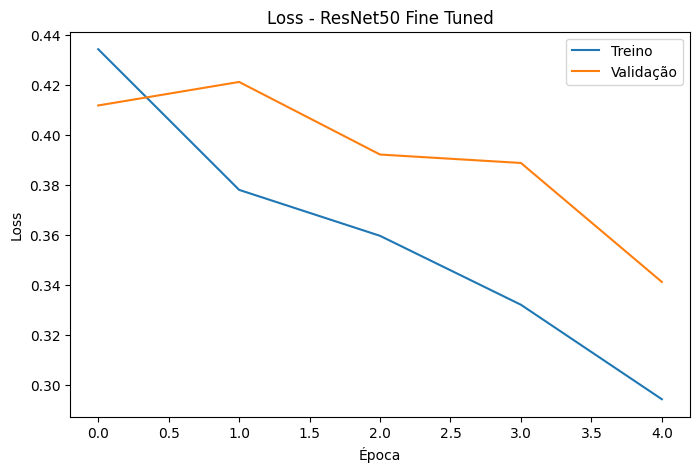

In [70]:
history_df = pd.DataFrame(history_resnet_finetune.history)
history_df.to_csv(f'{RESULTS_DIR}/history_resnet50_finetuned.csv', index=False)

plt.figure(figsize=(8,5))
plt.plot(history_resnet_finetune.history['accuracy'], label='Treino')
plt.plot(history_resnet_finetune.history['val_accuracy'], label='Validação')
plt.title('Acurácia - ResNet50 Fine Tuned')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.savefig(f'{RESULTS_DIR}/accuracy_resnet50_finetuned.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_resnet_finetune.history['loss'], label='Treino')
plt.plot(history_resnet_finetune.history['val_loss'], label='Validação')
plt.title('Loss - ResNet50 Fine Tuned')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'{RESULTS_DIR}/loss_resnet50_finetuned.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
experiment_metadata = {
    "author": "Lucas Marques",
    "project": "Classificação Computacional de Lesões Cutâneas Sugestivas de Câncer de Pele",
    "dataset": "HAM10000",
    "total_images": 10015,
    "task": "Classificação binária",
    "classes": {
        "0": "nao_suspeito",
        "1": "suspeito"
    },
    "suspect_classes": ["mel", "bcc", "akiec"],
    "non_suspect_classes": ["nv", "bkl", "vasc", "df"],
    "train_size": len(train_df),
    "validation_size": len(val_df),
    "test_size": len(test_df),
    "best_model": "ResNet50 Fine Tuned",
    "best_model_file": "resnet50_finetuned.keras",
    "image_size": "224x224",
    "framework": "TensorFlow/Keras"
}

with open(f'{RESULTS_DIR}/experiment_metadata.json', 'w') as f:
    json.dump(experiment_metadata, f, indent=4)

In [72]:
print("Modelos:")
print(os.listdir(MODEL_DIR))

print("\nResultados:")
print(os.listdir(RESULTS_DIR))

Modelos:
['resnet50_transfer_learning_baseline.keras', 'resnet50_finetuned.keras', 'cnn_baseline.keras']

Resultados:
['metrics_comparison.csv', 'confusion_matrix_resnet50_finetuned.png', 'gradcam_examples', 'classification_report_resnet50_finetuned.json', 'classification_report_resnet50_finetuned.csv', 'test_predictions_resnet50_finetuned.csv', 'history_resnet50_finetuned.csv', 'accuracy_resnet50_finetuned.png', 'loss_resnet50_finetuned.png', 'experiment_metadata.json']


In [73]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam

In [74]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [75]:
train_generator_eff = train_datagen_eff.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

val_generator_eff = val_test_datagen_eff.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator_eff = val_test_datagen_eff.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='binary_label_name',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.


In [76]:
base_eff = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_eff.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [77]:
eff_model = tf.keras.Sequential([
    base_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

eff_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [78]:
history_eff = eff_model.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 228s 896ms/step - accuracy: 0.6879 - loss: 0.5870 - val_accuracy: 0.7723 - val_loss: 0.4791
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 157s 716ms/step - accuracy: 0.7362 - loss: 0.4981 - val_accuracy: 0.7610 - val_loss: 0.4537
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 159s 722ms/step - accuracy: 0.7394 - loss: 0.4793 - val_accuracy: 0.7517 - val_loss: 0.4834
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 159s 723ms/step - accuracy: 0.7468 - loss: 0.4650 - val_accuracy: 0.7923 - val_loss: 0.4248
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 159s 719ms/step - accuracy: 0.7485 - loss: 0.4584 - val_accuracy: 0.7563 - val_loss: 0.4717


In [79]:
from sklearn.metrics import classification_report, confusion_matrix

test_generator_eff.reset()

pred_probs_eff = eff_model.predict(test_generator_eff)
pred_classes_eff = (pred_probs_eff > 0.5).astype(int).ravel()

true_classes_eff = test_generator_eff.classes

print(classification_report(
    true_classes_eff,
    pred_classes_eff,
    target_names=['nao_suspeito', 'suspeito']
))

print(confusion_matrix(true_classes_eff, pred_classes_eff))

47/47 ━━━━━━━━━━━━━━━━━━━━ 39s 609ms/step
              precision    recall  f1-score   support

nao_suspeito       0.94      0.77      0.85      1210
    suspeito       0.45      0.79      0.58       293

    accuracy                           0.77      1503
   macro avg       0.70      0.78      0.71      1503
weighted avg       0.84      0.77      0.79      1503

[[931 279]
 [ 61 232]]


In [80]:
eff_model.save(f'{MODEL_DIR}/efficientnetb0.keras')

In [81]:
metrics_data = [
    {
        "modelo": "CNN baseline",
        "accuracy": 0.81,
        "precision_suspeito": 0.00,
        "recall_suspeito": 0.00,
        "f1_suspeito": 0.00
    },
    {
        "modelo": "ResNet50 Transfer Learning",
        "accuracy": 0.79,
        "precision_suspeito": 0.47,
        "recall_suspeito": 0.86,
        "f1_suspeito": 0.61
    },
    {
        "modelo": "ResNet50 Fine Tuned",
        "accuracy": 0.86,
        "precision_suspeito": 0.60,
        "recall_suspeito": 0.77,
        "f1_suspeito": 0.68
    },
    {
        "modelo": "EfficientNetB0",
        "accuracy": 0.77,
        "precision_suspeito": 0.45,
        "recall_suspeito": 0.79,
        "f1_suspeito": 0.58
    }
]

metrics_df = pd.DataFrame(metrics_data)

metrics_df.to_csv(
    f'{RESULTS_DIR}/metrics_comparison.csv',
    index=False
)

metrics_df

,modelo,accuracy,precision_suspeito,recall_suspeito,f1_suspeito
0,CNN baseline,0.81,0.00,0.00,0.00
1,ResNet50 Transfer Learning,0.79,0.47,0.86,0.61
2,ResNet50 Fine Tuned,0.86,0.60,0.77,0.68
3,EfficientNetB0,0.77,0.45,0.79,0.58


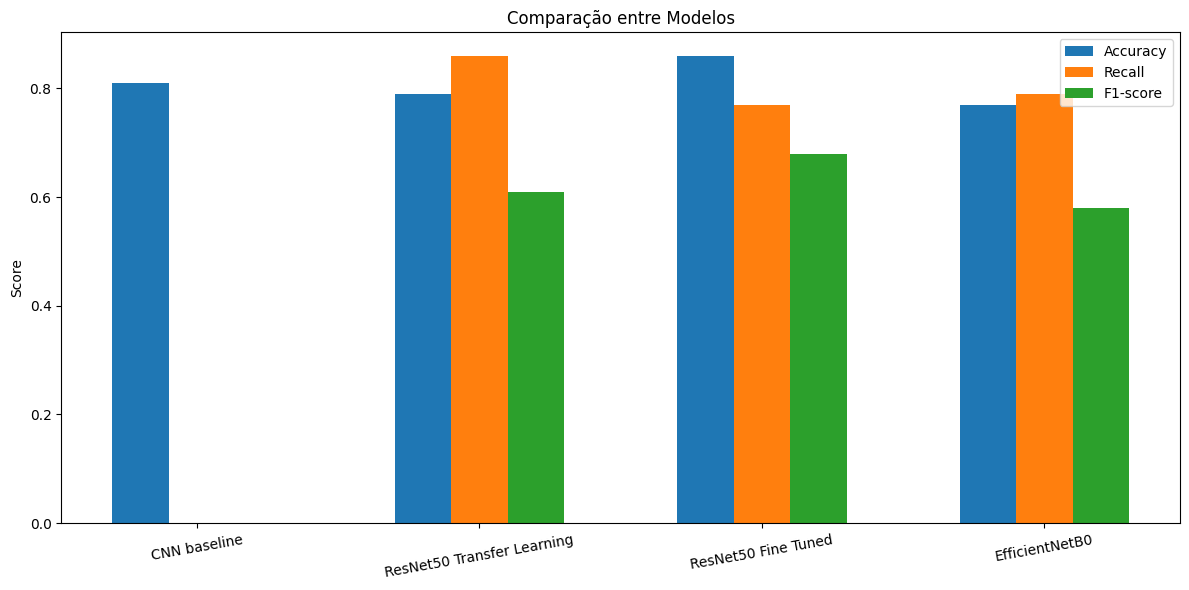

In [82]:
import matplotlib.pyplot as plt
import numpy as np

models_names = metrics_df['modelo']

x = np.arange(len(models_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(x - width, metrics_df['accuracy'], width, label='Accuracy')
ax.bar(x, metrics_df['recall_suspeito'], width, label='Recall')
ax.bar(x + width, metrics_df['f1_suspeito'], width, label='F1-score')

ax.set_ylabel('Score')
ax.set_title('Comparação entre Modelos')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=10)

ax.legend()

plt.tight_layout()

plt.savefig(
    f'{RESULTS_DIR}/models_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [83]:
history_eff_df = pd.DataFrame(history_eff.history)

history_eff_df.to_csv(
    f'{RESULTS_DIR}/history_efficientnet.csv',
    index=False
)

In [84]:
report_eff = classification_report(
    true_classes_eff,
    pred_classes_eff,
    target_names=['nao_suspeito', 'suspeito'],
    output_dict=True
)

pd.DataFrame(report_eff).transpose().to_csv(
    f'{RESULTS_DIR}/classification_report_efficientnet.csv'
)

In [85]:
import os

def save_gradcam(img_path, model, last_conv_layer_name, output_path, alpha=0.4):

    img = Image.open(img_path).resize((224, 224)).convert("RGB")

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array.copy())

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    heatmap = Image.fromarray(
        np.uint8(255 * heatmap)
    ).resize((224, 224))

    heatmap = np.array(heatmap)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=alpha)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches='tight')

    plt.close()

In [86]:
save_gradcam(
    sample_tp['path'],
    resnet_model,
    "conv5_block3_out",
    f"{GRADCAM_DIR}/true_positive.png"
)

In [87]:
save_gradcam(
    sample_tn['path'],
    resnet_model,
    "conv5_block3_out",
    f"{GRADCAM_DIR}/true_negative.png"
)

In [88]:
save_gradcam(
    sample_fp['path'],
    resnet_model,
    "conv5_block3_out",
    f"{GRADCAM_DIR}/false_positive.png"
)

In [89]:
save_gradcam(
    sample_fn['path'],
    resnet_model,
    "conv5_block3_out",
    f"{GRADCAM_DIR}/false_negative.png"
)

In [90]:
os.listdir(GRADCAM_DIR)

['true_positive.png',
 'true_negative.png',
 'false_positive.png',
 'false_negative.png']